# Evaluating the Impact of Prompting Strategies on Hallucination in Grounded QA
**Model:** FLAN-T5-large | **Dataset:** SQuAD (N=100) | **Annotation:** NLI-based (DeBERTa-v3) + human validation

## 1. Setup

In [1]:
!pip install transformers datasets torch scikit-learn matplotlib seaborn pandas -q

## 2. Load Dataset

In [2]:
from datasets import load_dataset

dataset   = load_dataset("squad", split="train[:120]")
questions = dataset["question"][:100]
answers   = [ans["text"][0] for ans in dataset["answers"][:100]]
contexts  = dataset["context"][:100]

print(f"Loaded {len(questions)} samples")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

Loaded 100 samples


## 3. Load Inference Model — FLAN-T5-large

In [3]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

gen_tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-large")
gen_model     = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-large").to(device)
gen_model.eval()
print("FLAN-T5-large loaded")

Device: cuda


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

FLAN-T5-large loaded


## 4. Generation Function

In [4]:
def generate(prompt):
    inputs  = gen_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)
    outputs = gen_model.generate(**inputs, max_new_tokens=60, do_sample=False, num_beams=4)
    return gen_tokenizer.decode(outputs[0], skip_special_tokens=True)

## 5. Prompting Strategies

In [5]:
def zero_shot(question, context):
    return (
        "Use the following context to answer the question concisely.\n\n"
        f"Context: {context}\n\nQuestion: {question}\nAnswer:"
    )

def few_shot(question, context):
    return (
        "Use the context to answer the questions concisely.\n\n"
        "Context: Pride and Prejudice was written by Jane Austen.\n"
        "Question: Who wrote Pride and Prejudice?\nAnswer: Jane Austen.\n\n"
        "Context: Tokyo is the capital city of Japan.\n"
        "Question: What is the capital of Japan?\nAnswer: Tokyo.\n\n"
        f"Context: {context}\nQuestion: {question}\nAnswer:"
    )

def chain_of_thought(question, context):
    return (
        "Use the context to answer the question. "
        "Think step by step before giving the final answer.\n\n"
        f"Context: {context}\n\nQuestion: {question}\nAnswer:"
    )

def constrained(question, context):
    return (
        "Answer only using the information provided in the context below. "
        "If the answer cannot be found in the context, respond with exactly: Not found.\n\n"
        f"Context: {context}\n\nQuestion: {question}\nAnswer:"
    )

STRATEGIES = [
    ("zero_shot",        zero_shot),
    ("few_shot",         few_shot),
    ("chain_of_thought", chain_of_thought),
    ("constrained",      constrained),
]

DISPLAY = {
    "zero_shot":        "Zero-shot",
    "few_shot":         "Few-shot",
    "chain_of_thought": "Chain-of-Thought",
    "constrained":      "Constrained",
}
ORDER = ["Zero-shot", "Few-shot", "Chain-of-Thought", "Constrained"]

## 6. Run Inference — 100 × 4 = 400 outputs

In [6]:
import pandas as pd

records = []
total   = len(questions) * len(STRATEGIES)

for i, (q, gold, ctx) in enumerate(zip(questions, answers, contexts)):
    for name, fn in STRATEGIES:
        records.append({
            "sample_id":   i,
            "question":    q,
            "context":     ctx,
            "gold_answer": gold,
            "strategy":    name,
            "response":    generate(fn(q, ctx)),
        })
    if (i + 1) % 25 == 0:
        print(f"  {(i+1)*len(STRATEGIES)}/{total} complete")

df = pd.DataFrame(records)
df.to_csv("raw_outputs.csv", index=False)  # checkpoint
print(f"Done. {len(df)} outputs. Saved to raw_outputs.csv")

  100/400 complete
  200/400 complete
  300/400 complete
  400/400 complete
Done. 400 outputs. Saved to raw_outputs.csv


## 7. Surface Metrics — Exact Match & Token F1

In [7]:
import re
import string
from collections import Counter

def normalize(text):
    text = text.lower()
    text = re.sub(r'\b(a|an|the)\b', ' ', text)
    text = ''.join(ch for ch in text if ch not in string.punctuation)
    return re.sub(r'\s+', ' ', text).strip()

def exact_match(pred, gold):
    return normalize(gold) in normalize(pred)

def token_f1(pred, gold):
    p_toks = normalize(pred).split()
    g_toks = normalize(gold).split()
    if not p_toks or not g_toks:
        return 0.0
    common = Counter(p_toks) & Counter(g_toks)
    nc     = sum(common.values())
    if nc == 0:
        return 0.0
    prec = nc / len(p_toks)
    rec  = nc / len(g_toks)
    return round(2 * prec * rec / (prec + rec), 4)

df["correct"]       = df.apply(lambda r: exact_match(r["response"], r["gold_answer"]), axis=1)
df["f1"]            = df.apply(lambda r: token_f1(r["response"], r["gold_answer"]), axis=1)
df["response_len"]  = df["response"].str.split().str.len()

print("Surface metrics computed.")
df[["strategy", "gold_answer", "response", "correct", "f1"]].head(8)

Surface metrics computed.


,strategy,gold_answer,response,correct,f1
0,zero_shot,Saint Bernadette Soubirous,Saint Bernadette Soubirous,True,1.0000
1,few_shot,Saint Bernadette Soubirous,Saint Bernadette Soubirous,True,1.0000
2,chain_of_thought,Saint Bernadette Soubirous,Saint Bernadette Soubirous,True,1.0000
3,constrained,Saint Bernadette Soubirous,Saint Bernadette Soubirous,True,1.0000
4,zero_shot,a copper statue of Christ,"Christ with arms upraised with the legend ""Ven...",False,0.1429
5,few_shot,a copper statue of Christ,"Christ with arms upraised with the legend ""Ven...",False,0.1429
6,chain_of_thought,a copper statue of Christ,"Christ with arms upraised with the legend ""Ven...",False,0.1429
7,constrained,a copper statue of Christ,"Christ with arms upraised with the legend ""Ven...",False,0.1429


## 8. Free FLAN-T5 Memory Before Loading NLI Model

In [8]:
import gc

del gen_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("FLAN-T5 unloaded — memory freed for NLI model.")

FLAN-T5 unloaded — memory freed for NLI model.


## 9. Load NLI Model — DeBERTa-v3

We use `cross-encoder/nli-deberta-v3-base`, a state-of-the-art NLI model, to classify each
generated response against its source context as:
- **entailment** — response is supported by context
- **neutral** — response is neither supported nor contradicted (extrinsic content)
- **contradiction** — response directly conflicts with context (intrinsic error)

In [9]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

NLI_MODEL = "cross-encoder/nli-deberta-v3-base"
nli_tokenizer = AutoTokenizer.from_pretrained(NLI_MODEL)
nli_model     = AutoModelForSequenceClassification.from_pretrained(NLI_MODEL).to(device)
nli_model.eval()

# Print the model's own label mapping so we know the index→label order
print("NLI label mapping:", nli_model.config.id2label)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: cross-encoder/nli-deberta-v3-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NLI label mapping: {0: 'contradiction', 1: 'entailment', 2: 'neutral'}


## 10. Automated Annotation Pipeline

### Decision logic per output:

| Condition | Label | Hallucination type | Error category |
|---|---|---|---|
| Contains refusal phrase | R | — | refusal |
| Exact match with gold | C | — | correct |
| NLI = contradiction | H | intrinsic | fabrication |
| NLI = neutral | H | extrinsic | fabrication |
| NLI = entailment (but wrong) | E | — | span/format |

> **E (extraction error):** response is grounded in context but does not match the gold span — likely a valid alternative answer or minor formatting mismatch, not a hallucination.

In [10]:
REFUSAL_PHRASES = [
    "not found", "cannot be found", "not mentioned", "not stated",
    "not provided", "i don't know", "unknown", "no information",
]

def is_refusal(text):
    t = text.lower()
    return any(p in t for p in REFUSAL_PHRASES)

df["auto_refusal"] = df["response"].apply(is_refusal)

In [11]:
def batch_nli(premises, hypotheses, batch_size=8):
    """
    Run NLI over lists of (premise, hypothesis) pairs in batches.
    Returns list of (label_str, confidence_float).
    """
    results = []
    for i in range(0, len(premises), batch_size):
        bp = premises[i : i + batch_size]
        bh = hypotheses[i : i + batch_size]
        enc = nli_tokenizer(
            bp, bh,
            return_tensors="pt",
            truncation=True,
            max_length=512,
            padding=True,
        ).to(device)
        with torch.no_grad():
            logits = nli_model(**enc).logits
        probs    = torch.softmax(logits, dim=-1)
        pred_ids = probs.argmax(dim=-1)
        for pred_id, prob_row in zip(pred_ids, probs):
            label = nli_model.config.id2label[pred_id.item()].lower()
            conf  = prob_row[pred_id.item()].item()
            results.append((label, conf))
    return results

In [12]:
# Run NLI only on rows that are NOT correct and NOT refusals
# (avoids wasting compute on clear-cut cases)
nli_mask = (~df["correct"]) & (~df["auto_refusal"])
nli_rows  = df[nli_mask]

print(f"Running NLI on {len(nli_rows)} ambiguous outputs (skipping {len(df)-len(nli_rows)} clear cases)...")

nli_results = batch_nli(
    nli_rows["context"].tolist(),
    nli_rows["response"].tolist(),
    batch_size=8
)

df["nli_label"]      = ""
df["nli_confidence"] = 0.0
df.loc[nli_mask, "nli_label"]      = [r[0] for r in nli_results]
df.loc[nli_mask, "nli_confidence"] = [r[1] for r in nli_results]

print("NLI complete.")
print(df.loc[nli_mask, "nli_label"].value_counts())

Running NLI on 67 ambiguous outputs (skipping 333 clear cases)...
NLI complete.
nli_label
neutral          57
entailment        6
contradiction     4
Name: count, dtype: int64


In [13]:
def assign_label(row):
    """
    Assign final annotation label, hallucination type, and error category
    using the three-step decision logic.
    """
    # Step 1 — Refusal
    if row["auto_refusal"]:
        return "R", "", "refusal"

    # Step 2 — Exact match
    if row["correct"]:
        return "C", "", "correct"

    # Step 3 — NLI verdict
    nli = row["nli_label"]
    if nli == "contradiction":
        return "H", "intrinsic",  "fabrication"
    elif nli == "neutral":
        return "H", "extrinsic",  "fabrication"
    else:  # entailment — grounded but wrong span / format
        return "E", "",           "span"

labels = df.apply(assign_label, axis=1, result_type="expand")
labels.columns = ["label", "hallucination_type", "error_category"]
df = pd.concat([df, labels], axis=1)

print("\nFinal label distribution:")
print(df["label"].value_counts())
print("\nHallucination type (H rows only):")
print(df.loc[df["label"]=="H", "hallucination_type"].value_counts())


Final label distribution:
label
C    323
H     61
R     10
E      6
Name: count, dtype: int64

Hallucination type (H rows only):
hallucination_type
extrinsic    57
intrinsic     4
Name: count, dtype: int64


## 11. Human Validation — Measuring NLI Annotation Quality

We randomly sample **40 outputs** (10 per strategy, stratified) and have a human annotator
label them independently. We then compute Cohen's kappa to measure agreement between the
NLI system and the human annotator.

In [14]:
import numpy as np

np.random.seed(42)

val_frames = []
for strat in df["strategy"].unique():
    pool    = df[df["strategy"] == strat]
    sampled = pool.sample(min(10, len(pool)), random_state=42)
    val_frames.append(sampled)

val_df = pd.concat(val_frames).reset_index(drop=True)
val_df["human_label"] = ""   # <-- to be filled in the next cell

# Export for review
val_df[["strategy","question","context","gold_answer","response","label","human_label"]].to_csv(
    "validation_sample.csv", index=True
)

print(f"Validation sample: {len(val_df)} rows")
print("Saved to validation_sample.csv")
print("\nNLI labels assigned to validation set:")
print(val_df["label"].value_counts())
print("\nOpen validation_sample.csv, read each row, fill in 'human_label' column")
print("with C / H / R / E, then paste into the dict in the next cell.")

Validation sample: 40 rows
Saved to validation_sample.csv

NLI labels assigned to validation set:
label
C    33
H     6
R     1
Name: count, dtype: int64

Open validation_sample.csv, read each row, fill in 'human_label' column
with C / H / R / E, then paste into the dict in the next cell.


In [16]:
import pandas as pd
val = pd.read_csv("validation_sample.csv")
pd.set_option("display.max_colwidth", 80)
display(val[["strategy", "question", "context", "gold_answer", "response", "label"]])

,strategy,question,context,gold_answer,response,label
0,zero_shot,What is Congregation of Holy Cross in Latin?,The university is affiliated with the Congregation of Holy Cross (Latin: Con...,Congregatio a Sancta Cruce,"Congregatio a Sancta Cruce, abbreviated postnominal",C
1,zero_shot,What professorship did Father Josh Carrier hold at Notre Dame?,"Father Joseph Carrier, C.S.C. was Director of the Science Museum and the Lib...",Professor of Chemistry and Physics,Director of the Science Museum and the Library and Professor of Chemistry an...,C
2,zero_shot,What does the Kroc Institute at Notre Dame focus on?,As of 2012[update] research continued in many fields. The university preside...,International Peace studies,for International Peace studies,C
3,zero_shot,Forbes.com placed Notre Dame at what position compared to other US research ...,"In 2015-2016, Notre Dame ranked 18th overall among ""national universities"" i...",8th,"8th among Research Universities, and 1st in the Midwest",C
4,zero_shot,Where did U.S. News & World Report rank Notre Dame in its 2015-2016 universi...,"In 2015-2016, Notre Dame ranked 18th overall among ""national universities"" i...",18th overall,"18th among ""national universities"" in the United States in U.S. News & World...",H
5,zero_shot,How many incoming students did Notre Dame admit in fall 2015?,"Notre Dame is known for its competitive admissions, with the incoming class ...","3,577","3,577",C
6,zero_shot,What was created at Notre Dame in 1962 to assist first year students?,All of Notre Dame's undergraduate students are a part of one of the five und...,The First Year of Studies program,The First Year of Studies,H
7,zero_shot,How many dorms for males are on the Notre Dame campus?,About 80% of undergraduates and 20% of graduate students live on campus. The...,15,15 male dorms,C
8,zero_shot,Where is the headquarters of the Congregation of the Holy Cross?,The university is the major seat of the Congregation of Holy Cross (albeit n...,Rome,Rome,C
9,zero_shot,To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?,"Architecturally, the school has a Catholic character. Atop the Main Building...",Saint Bernadette Soubirous,Saint Bernadette Soubirous,C


In [17]:
# -------------------------------------------------------------------------
# HUMAN LABELS — fill these in after reviewing validation_sample.csv
# Keys are the DataFrame row indices printed above.
# Values are your label: "C" | "H" | "R" | "E"
# -------------------------------------------------------------------------

human_labels = {
    0:  "C",
    1:  "C",
    2:"C",
    3:"C",
    4:"E",
    5:"C",
    6:"C",
    7:"C",
    8:"C",
    9:"C",
    10:"C",
    11:"E",
    12:"C",
    13:"C",
    14:"H",
    15:"C",
    16:"C",
    17:"C",
    18:"C",
    19:"C",
    20:"C",
    21:"C",
    22:"C",
    23:"C",
    24:"C",
    25:"C",
    26:"C",
    27:"C",
    28:"C",
    29:"C",
    30:"C",
    31:"C",
    32:"C",
    33:"C",
    34:"C",
    35:"C",
    36:"C",
    37:"C",
    38:"R",
    39:"C"

    }

if len(human_labels) == len(val_df):
    val_df["human_label"] = val_df.index.map(human_labels)

    from sklearn.metrics import cohen_kappa_score, classification_report

    nli_preds   = val_df["label"].tolist()
    human_preds = val_df["human_label"].tolist()

    kappa   = cohen_kappa_score(human_preds, nli_preds)
    agree   = sum(n == h for n, h in zip(nli_preds, human_preds)) / len(nli_preds)

    print(f"Agreement:    {agree*100:.1f}%")
    print(f"Cohen's κ:    {kappa:.3f}  ", end="")
    if kappa >= 0.80:
        print("(almost perfect)")
    elif kappa >= 0.60:
        print("(substantial)")
    elif kappa >= 0.40:
        print("(moderate)")
    else:
        print("(fair — consider reviewing NLI thresholds)")

    print("\nClassification Report (NLI vs Human):")
    print(classification_report(human_preds, nli_preds,
                                labels=["C","H","R","E"], zero_division=0))

    # Save validation results
    val_df.to_csv("validation_results.csv", index=False)
else:
    n_filled = sum(1 for v in human_labels.values() if v)
    print(f" {n_filled}/40 human labels filled in.")
    print("Fill all 40 in the dict above, then re-run this cell.")

Agreement:    85.0%
Cohen's κ:    0.407  (moderate)

Classification Report (NLI vs Human):
              precision    recall  f1-score   support

           C       0.97      0.89      0.93        36
           H       0.17      1.00      0.29         1
           R       1.00      1.00      1.00         1
           E       0.00      0.00      0.00         2

    accuracy                           0.85        40
   macro avg       0.53      0.72      0.55        40
weighted avg       0.90      0.85      0.87        40



## 12. Results Summary

In [18]:
grouped = df.groupby("strategy")
n_per   = grouped.size()

def rate(label):
    counts = df[df["label"]==label].groupby("strategy").size().reindex(
        grouped.groups.keys(), fill_value=0)
    return (counts / n_per * 100).round(2)

summary = pd.DataFrame({
    "Exact Match (%)": (grouped["correct"].mean() * 100).round(2),
    "F1 Score (%)": (grouped["f1"].mean() * 100).round(2),
    "Hallucination Rate (%)": rate("H"),
    "Extraction Error (%)": rate("E"),
    "Refusal Rate (%)": rate("R"),
})

summary.index = summary.index.map(DISPLAY)
summary = summary.reindex(ORDER)

print("=== Results Summary (N=100 per strategy) ===")
display(summary)

=== Results Summary (N=100 per strategy) ===


,Exact Match (%),F1 Score (%),Hallucination Rate (%),Extraction Error (%),Refusal Rate (%)
strategy,,,,,
Zero-shot,82.0,65.35,17.0,1.0,0.0
Few-shot,82.0,61.49,17.0,1.0,0.0
Chain-of-Thought,83.0,31.01,13.0,4.0,0.0
Constrained,76.0,60.48,14.0,0.0,10.0


## 13. Hallucination Type Analysis

In [19]:
hall_df = df[df["label"] == "H"].copy()
hall_df["Strategy"] = hall_df["strategy"].map(DISPLAY)

type_counts = (
    hall_df.groupby(["Strategy", "hallucination_type"]).size()
    .unstack(fill_value=0)
    .reindex(ORDER)
)
type_pct = (type_counts / 100 * 100).round(2)

print("=== Hallucination Type (% of all outputs per strategy) ===")
display(type_pct)

if len(hall_df) > 0:
    total_h = len(hall_df)
    intro   = (hall_df["hallucination_type"] == "intrinsic").sum()
    extro   = (hall_df["hallucination_type"] == "extrinsic").sum()
    print(f"\nTotal hallucinations: {total_h}")
    print(f"  Intrinsic : {intro} ({intro/total_h*100:.1f}%) — contradicts context")
    print(f"  Extrinsic : {extro} ({extro/total_h*100:.1f}%) — introduces unsupported info")

=== Hallucination Type (% of all outputs per strategy) ===


hallucination_type,extrinsic,intrinsic
Strategy,,
Zero-shot,16.0,1.0
Few-shot,16.0,1.0
Chain-of-Thought,12.0,1.0
Constrained,13.0,1.0



Total hallucinations: 61
  Intrinsic : 4 (6.6%) — contradicts context
  Extrinsic : 57 (93.4%) — introduces unsupported info


## 14. Error Analysis

In [20]:
# --- 14a. Error category breakdown ---
err_df = df[df["label"] != "C"].copy()
err_df["Strategy"] = err_df["strategy"].map(DISPLAY)

err_counts = (
    err_df.groupby(["Strategy", "error_category"]).size()
    .unstack(fill_value=0)
    .reindex(ORDER)
)

print("=== Error Category Counts ===")
display(err_counts)

err_pct = err_counts.div(err_counts.sum(axis=1), axis=0).mul(100).round(1)
print("\n=== Error Category % (within each strategy's errors) ===")
display(err_pct)

=== Error Category Counts ===


error_category,fabrication,refusal,span
Strategy,,,
Zero-shot,17,0,1
Few-shot,17,0,1
Chain-of-Thought,13,0,4
Constrained,14,10,0



=== Error Category % (within each strategy's errors) ===


error_category,fabrication,refusal,span
Strategy,,,
Zero-shot,94.4,0.0,5.6
Few-shot,94.4,0.0,5.6
Chain-of-Thought,76.5,0.0,23.5
Constrained,58.3,41.7,0.0


In [21]:
# --- 14b. Response length by label ---
len_table = (
    df.groupby(["strategy", "label"])["response_len"]
    .mean().round(1).unstack()
)
len_table.index = len_table.index.map(DISPLAY)
len_table = len_table.reindex(ORDER)

print("=== Mean Response Length (words) by Strategy and Label ===")
display(len_table)

=== Mean Response Length (words) by Strategy and Label ===


label,C,E,H,R
strategy,,,,
Zero-shot,6.9,35.0,4.2,NaN
Few-shot,7.7,19.0,3.6,NaN
Chain-of-Thought,21.7,21.8,18.2,NaN
Constrained,6.4,NaN,3.4,2.0


In [22]:
# --- 14c. Constrained strategy refusal analysis ---
con_df    = df[df["strategy"] == "constrained"]
refused   = con_df[con_df["auto_refusal"]]
answered  = con_df[~con_df["auto_refusal"]]

print("=== Constrained Strategy: Refusal Analysis ===")
print(f"Total        : {len(con_df)}")
print(f"Refused      : {len(refused)} ({len(refused)/len(con_df)*100:.1f}%)")
print(f"Answered     : {len(answered)} ({len(answered)/len(con_df)*100:.1f}%)")
if len(answered) > 0:
    hall_in_ans = (answered["label"] == "H").sum()
    print(f"\nAmong answered outputs:")
    print(f"  Exact match     : {answered['correct'].mean()*100:.1f}%")
    print(f"  Mean F1         : {answered['f1'].mean()*100:.1f}%")
    print(f"  Hallucinations  : {hall_in_ans} ({hall_in_ans/len(answered)*100:.1f}%)")

=== Constrained Strategy: Refusal Analysis ===
Total        : 100
Refused      : 10 (10.0%)
Answered     : 90 (90.0%)

Among answered outputs:
  Exact match     : 84.4%
  Mean F1         : 67.2%
  Hallucinations  : 14 (15.6%)


## 15. Visualizations

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
COLORS = {
    "Zero-shot":        "#4C72B0",
    "Few-shot":         "#55A868",
    "Chain-of-Thought": "#C44E52",
    "Constrained":      "#DD8452",
}
CLIST = [COLORS[s] for s in ORDER]
x = np.arange(len(ORDER))

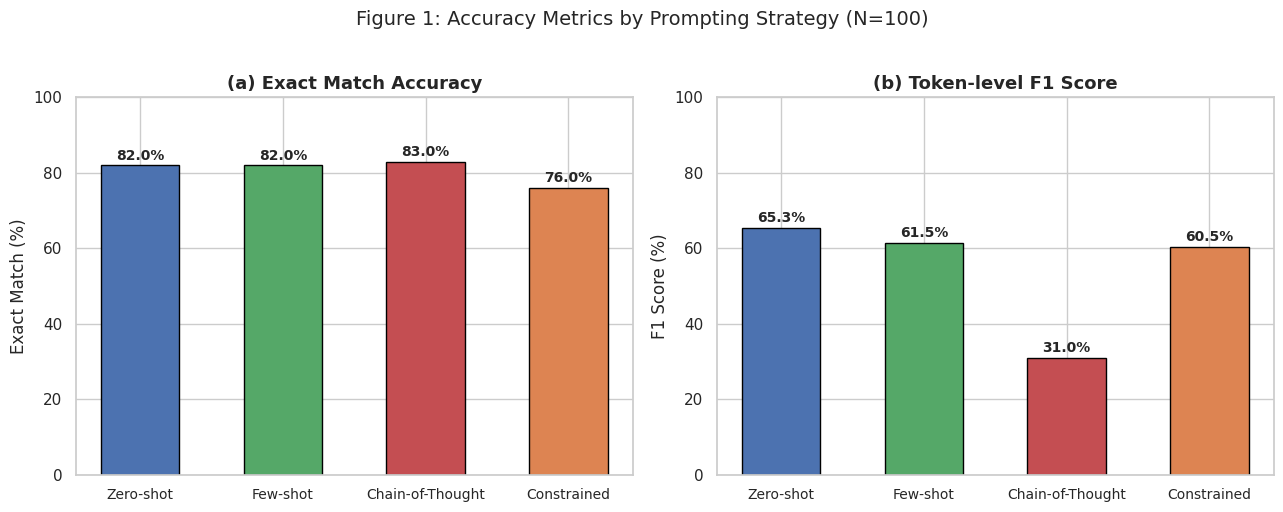

Saved: fig1_accuracy.png


In [24]:
# Figure 1 — Exact Match & F1
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, title, ylabel in [
    (axes[0], "Exact Match (%)", "(a) Exact Match Accuracy", "Exact Match (%)"),
    (axes[1], "F1 Score (%)",    "(b) Token-level F1 Score",  "F1 Score (%)"),
]:
    vals = summary.loc[ORDER, col]
    bars = ax.bar(x, vals, color=CLIST, edgecolor="black", width=0.55)
    ax.set_xticks(x); ax.set_xticklabels(ORDER, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylim(0, 100)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+1.5,
                f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")
plt.suptitle("Figure 1: Accuracy Metrics by Prompting Strategy (N=100)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("fig1_accuracy.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: fig1_accuracy.png")

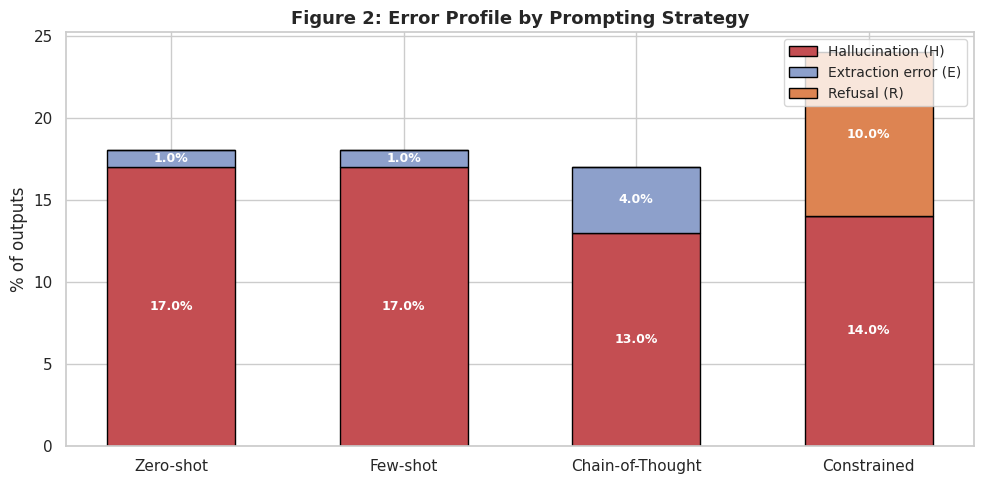

Saved: fig2_error_profile.png


In [25]:
# Figure 2 — Error profile: H / E / R stacked bar
fig, ax = plt.subplots(figsize=(10, 5))
bot = np.zeros(len(ORDER))
for col, color, lbl in [
    ("Hallucination Rate (%)", "#C44E52", "Hallucination (H)"),
    ("Extraction Error (%)",   "#8da0cb", "Extraction error (E)"),
    ("Refusal Rate (%)",       "#DD8452", "Refusal (R)"),
]:
    vals = summary.loc[ORDER, col].values
    ax.bar(x, vals, bottom=bot, label=lbl, color=color, edgecolor="black", width=0.55)
    for i, v in enumerate(vals):
        if v > 0:
            ax.text(i, bot[i]+v/2, f"{v:.1f}%",
                    ha="center", va="center", fontsize=9, fontweight="bold", color="white")
    bot += vals
ax.set_xticks(x); ax.set_xticklabels(ORDER, fontsize=11)
ax.set_ylabel("% of outputs", fontsize=12)
ax.set_title("Figure 2: Error Profile by Prompting Strategy",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10, loc="upper right")
plt.tight_layout()
plt.savefig("fig2_error_profile.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: fig2_error_profile.png")

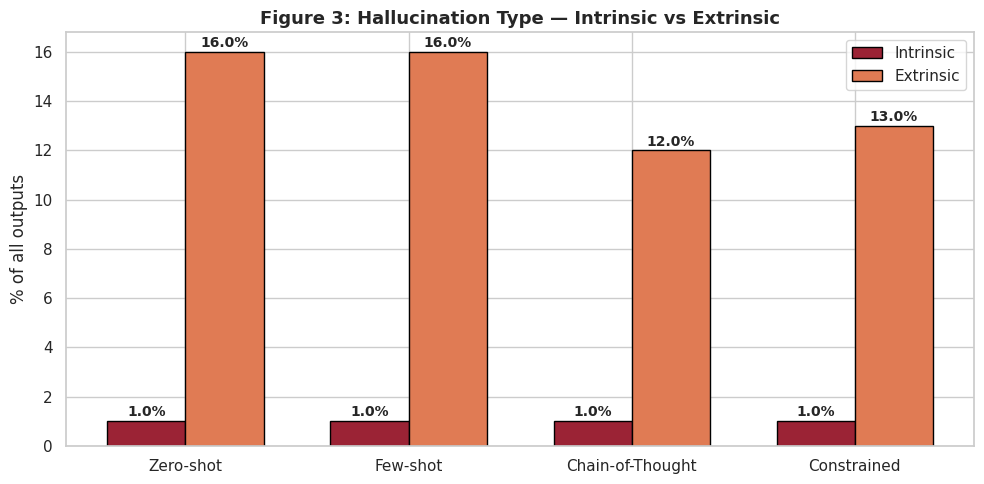

Saved: fig3_hall_type.png


In [26]:
# Figure 3 — Intrinsic vs Extrinsic hallucination split
if len(hall_df) > 0 and all(c in type_pct.columns for c in ["intrinsic","extrinsic"]):
    fig, ax = plt.subplots(figsize=(10, 5))
    w = 0.35
    b1 = ax.bar(x-w/2, type_pct.get("intrinsic", 0), w,
                label="Intrinsic", color="#9b2335", edgecolor="black")
    b2 = ax.bar(x+w/2, type_pct.get("extrinsic", 0), w,
                label="Extrinsic", color="#e07b54", edgecolor="black")
    for bar, v in list(zip(b1, type_pct.get("intrinsic",pd.Series([0]*4)).values)) + \
                  list(zip(b2, type_pct.get("extrinsic",pd.Series([0]*4)).values)):
        if v > 0:
            ax.text(bar.get_x()+bar.get_width()/2, v+0.2,
                    f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(ORDER, fontsize=11)
    ax.set_ylabel("% of all outputs", fontsize=12)
    ax.set_title("Figure 3: Hallucination Type — Intrinsic vs Extrinsic",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig("fig3_hall_type.png", dpi=150, bbox_inches="tight")
    plt.show(); print("Saved: fig3_hall_type.png")

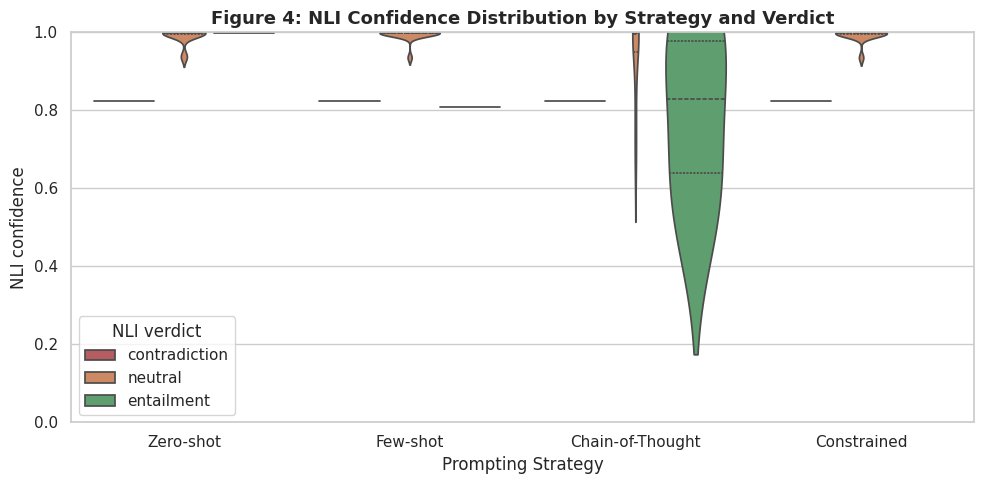

Saved: fig4_nli_confidence.png


In [27]:
# Figure 4 — NLI confidence distribution (violin)
nli_plot = df[nli_mask].copy()
nli_plot["Strategy"] = nli_plot["strategy"].map(DISPLAY)
nli_plot["NLI verdict"] = nli_plot["nli_label"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(
    data=nli_plot, x="Strategy", y="nli_confidence",
    hue="NLI verdict", order=ORDER,
    palette={"contradiction":"#C44E52","neutral":"#DD8452","entailment":"#55A868"},
    split=False, inner="quartile", ax=ax
)
ax.set_ylabel("NLI confidence", fontsize=12)
ax.set_xlabel("Prompting Strategy", fontsize=12)
ax.set_title("Figure 4: NLI Confidence Distribution by Strategy and Verdict",
             fontsize=13, fontweight="bold")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("fig4_nli_confidence.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: fig4_nli_confidence.png")

/tmp/ipykernel_1277/4020287035.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="Strategy", y="f1", order=ORDER,


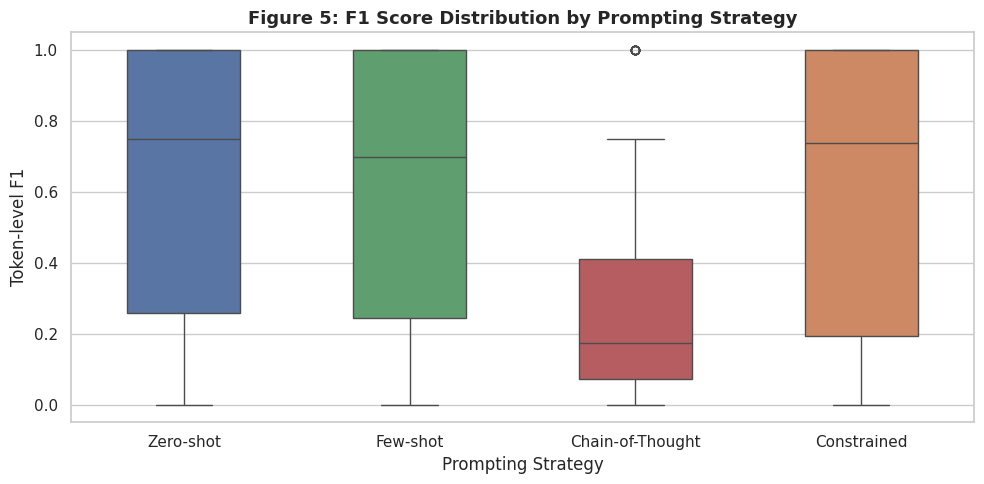

Saved: fig5_f1_dist.png


In [28]:
# Figure 5 — F1 distribution (box)
df_plot = df.copy()
df_plot["Strategy"] = df_plot["strategy"].map(DISPLAY)
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_plot, x="Strategy", y="f1", order=ORDER,
            palette=COLORS, ax=ax, width=0.5)
ax.set_ylabel("Token-level F1", fontsize=12)
ax.set_xlabel("Prompting Strategy", fontsize=12)
ax.set_title("Figure 5: F1 Score Distribution by Prompting Strategy",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig5_f1_dist.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: fig5_f1_dist.png")

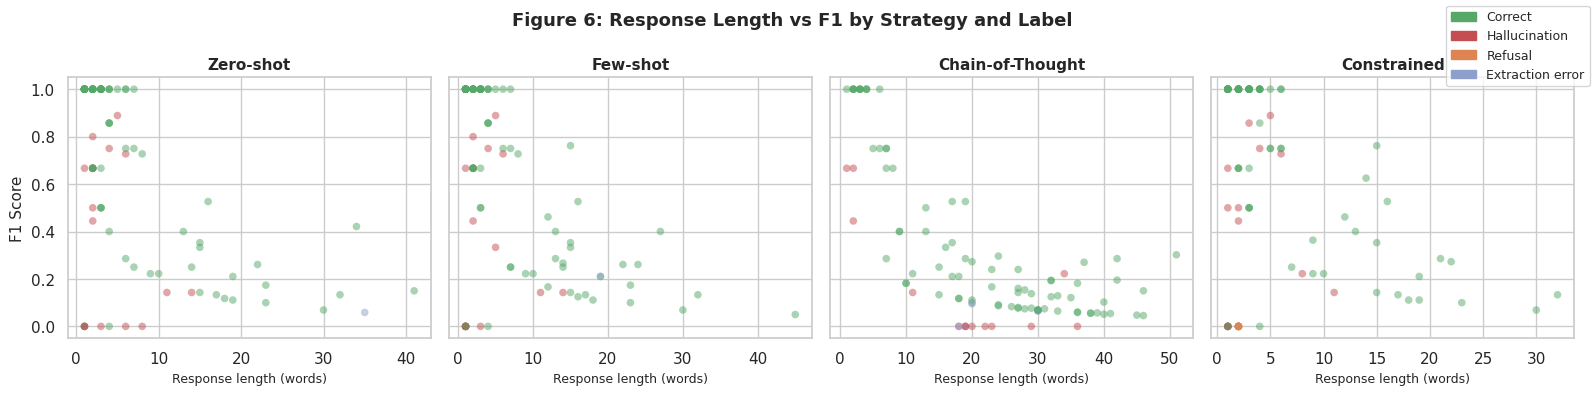

Saved: fig6_len_f1.png


In [29]:
# Figure 6 — Response length vs F1 (coloured by label)
LABEL_COLORS = {"C":"#55A868", "H":"#C44E52", "R":"#DD8452", "E":"#8da0cb"}
df_plot2 = df.copy()
df_plot2["Strategy"] = df_plot2["strategy"].map(DISPLAY)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, strat in zip(axes, ORDER):
    sub = df_plot2[df_plot2["Strategy"] == strat]
    ax.scatter(
        sub["response_len"], sub["f1"],
        c=sub["label"].map(LABEL_COLORS).fillna("gray"),
        alpha=0.5, s=30, edgecolors="none"
    )
    ax.set_title(strat, fontsize=11, fontweight="bold")
    ax.set_xlabel("Response length (words)", fontsize=9)
axes[0].set_ylabel("F1 Score", fontsize=11)
handles = [mpatches.Patch(color=c, label=l)
           for l, c in {"Correct":"#55A868","Hallucination":"#C44E52",
                        "Refusal":"#DD8452","Extraction error":"#8da0cb"}.items()]
fig.legend(handles=handles, loc="upper right", fontsize=9)
plt.suptitle("Figure 6: Response Length vs F1 by Strategy and Label",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig6_len_f1.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: fig6_len_f1.png")

## 16. Qualitative Examples

In [30]:
pd.set_option("display.max_colwidth", 90)
COLS = ["strategy","question","gold_answer","response","nli_label","nli_confidence"]

print("=== Intrinsic Hallucinations (NLI: contradiction) ===")
display(df[(df["label"]=="H")&(df["hallucination_type"]=="intrinsic")][COLS].head(4))

print("\n=== Extrinsic Hallucinations (NLI: neutral) ===")
display(df[(df["label"]=="H")&(df["hallucination_type"]=="extrinsic")][COLS].head(4))

print("\n=== Extraction Errors (NLI: entailment, wrong gold) ===")
display(df[df["label"]=="E"][["strategy","question","gold_answer","response"]].head(4))

print("\n=== Constrained Refusals ===")
display(df[(df["strategy"]=="constrained")&(df["auto_refusal"])]
        [["question","gold_answer","response"]].head(5))

=== Intrinsic Hallucinations (NLI: contradiction) ===


,strategy,question,gold_answer,response,nli_label,nli_confidence
4,zero_shot,What is in front of the Notre Dame Main Building?,a copper statue of Christ,"Christ with arms upraised with the legend ""Venite Ad Me Omnes",contradiction,0.822682
5,few_shot,What is in front of the Notre Dame Main Building?,a copper statue of Christ,"Christ with arms upraised with the legend ""Venite Ad Me Omnes",contradiction,0.822682
6,chain_of_thought,What is in front of the Notre Dame Main Building?,a copper statue of Christ,"Christ with arms upraised with the legend ""Venite Ad Me Omnes",contradiction,0.822682
7,constrained,What is in front of the Notre Dame Main Building?,a copper statue of Christ,"Christ with arms upraised with the legend ""Venite Ad Me Omnes",contradiction,0.822682



=== Extrinsic Hallucinations (NLI: neutral) ===


,strategy,question,gold_answer,response,nli_label,nli_confidence
34,chain_of_thought,How many student news papers are found at Notre Dame?,three,"To answer this question, we should know that it is not possible to answer this questio...",neutral,0.997465
62,chain_of_thought,How many BS level degrees are offered in the College of Engineering at Notre Dame?,eight,"To answer this question, we should know that: Today the college, housed in the Fitzpat...",neutral,0.738235
64,zero_shot,In what year was the College of Engineering at Notre Dame formed?,1920,20,neutral,0.999274
65,few_shot,In what year was the College of Engineering at Notre Dame formed?,1920,2021,neutral,0.999159



=== Extraction Errors (NLI: entailment, wrong gold) ===


,strategy,question,gold_answer,response
262,chain_of_thought,What was the Review of Politics inspired by?,German Catholic journals,"To answer this question, we should know the following: It quickly emerged as part of a..."
270,chain_of_thought,Thomas Stritch was an editor of which publican from Notre Dame?,Review of Politics,"To answer this question, we should know that: For 44 years, the Review was edited by G..."
302,chain_of_thought,How many teams participate in the Notre Dame Bookstore Basketball tournament?,over 700,"To answer this question, we should know that: The annual Bookstore Basketball tourname..."
358,chain_of_thought,In what year was the Main Building at Notre Dame razed in a fire?,1879,"To answer this question, we should know that: This Main Building, and the library coll..."



=== Constrained Refusals ===


,question,gold_answer,response
11,The Basilica of the Sacred heart at Notre Dame is beside to which structure?,the Main Building,Not found
43,Where is the headquarters of the Congregation of the Holy Cross?,Rome,Not found
99,The granting of Doctorate degrees first occurred in what year at Notre Dame?,1924,Not found
131,To whom was John B. Kroc married?,Ray Kroc,Not found
135,What company did Ray Kroc own?,McDonald's,Not found


## 17. Save All Results

In [31]:
df.to_csv("full_results.csv", index=False)
summary.to_csv("summary_table.csv")
type_pct.to_csv("hallucination_type_table.csv")
err_counts.to_csv("error_analysis_table.csv")

print("All results saved.")
print("\n=== Final Summary ===")
display(summary)

All results saved.

=== Final Summary ===


,Exact Match (%),F1 Score (%),Hallucination Rate (%),Extraction Error (%),Refusal Rate (%)
strategy,,,,,
Zero-shot,82.0,65.35,17.0,1.0,0.0
Few-shot,82.0,61.49,17.0,1.0,0.0
Chain-of-Thought,83.0,31.01,13.0,4.0,0.0
Constrained,76.0,60.48,14.0,0.0,10.0
